<h1>An Example of Mutation Plotting</h1>

Sometimes we would like to see the distribution of the probability caused by the mutation when we make a prediction. That is, we have to generate the mutated sequences and predict them by built model:

<b>python running.py --dataType dna --dataEncodingType onehot --dataTrainFilePaths examples/CRISPRCas9guideefficiency/data/Doench_high_activity_sgRNA.txt examples/CRISPRCas9guideefficiency/data/Doench_low_activity_sgRNA.txt --dataTrainLabel 1 0 --dataSplitScale 0.8 --modelLoadFile examples/CRISPRCas9guideefficiency/model/DNA_CNN2D_model.py --verbose 1 --outSaveFolderPath tmpOut --savePrediction 1 --saveFig 1 --batch_size 25 --epochs 40 --shuffleDataTrain 1 --spcLen 30 --modelSaveName tmpMod.json --weightSaveName tmpWeight.bin --noGPU 0 --paraSaveName parameters.txt</b>

Then generating the mutated sequences (<b>Note: the work dir is the root path of autoBioSeqpy</b>):

<b>python tool/generateMutatedSeqs.py --outFile tmpOut/mutatedSeqs.txt --withOri 1 --oriName tmp --randomly 1 --oriSeq GTTGTTGCAGTTGGATATAGACCACGGAGA --dataType dna
</b>

Make a prediction:

<b>python predicting.py --paraFile tmpOut/parameters.txt --dataTestFilePaths tmpOut/mutatedSeqs.txt --predictionSavePath tmpOut/indPredictions.txt</b>
    
Finally generating the difference matrix:

<b>python tool/findDiff.py tmpOut/indPredictions.txt > tmpOut/diffMat.txt</b>

In this notebook, we aim at plotting the predicted probability against the original one. This function is provided as a tool '<b>mutationPlot.py</b>' at the folder '<b>tool</b>'.

<h2>Preparing</h2>

In [1]:
import os, sys
sys.path.append('../')
import  re
sys.path.append(os.path.curdir)
sys.path.append(sys.argv[0])
import numpy as np
import analysisPlot

import matplotlib as mpl
import matplotlib.pyplot as plt

Using TensorFlow backend.


<h2>Reading the difference matrix</h2>

The file is the output from <b>findDiff.py</b>, users could change it as needed.

In [2]:
fileIn = '../tmpOut/diffMat.txt'

Reading the output and translate them into a matrix. Note that the parameter <b>oriIndex</b> is to specify the index of original sequence.

In [3]:
oriIndex = 0

In [4]:

#Name1 -- Name2\tIndex1 -- Index2\tPredction1 -- Prediction2\tprobDIff
subSep = ' -- '


proteinStr = 'GAVLIPFYWSTCMNQDEKRHXBJOUZ'
dnaStr = 'AGCT'
rnaStr = 'AGCU'

mutationDict = {} # position:ori:mutation
keySet = set()
with open(fileIn) as FID:     
    rowList = []
    rowOldInd = None
    for line in FID:
        if line.startswith('#'):
            continue
        eles = line.strip().split('\t')
        name1, name2 = eles[0].split(subSep)
        index1, index2 = eles[1].split(subSep)
        index1 = int(index1)
        index2 = int(index2)
        out1, out2 = eles[2].split(subSep)
        probDiff = float(eles[3])
        if index1 == oriIndex:
            position, oriRes, mutatedRes = re.findall('(\d+)_(\w)-(\w)',name2.split('###')[1])[0]
            position = int(position)
            if not position in mutationDict:
                mutationDict[position] = {}
            if not oriRes in mutationDict[position]:
                mutationDict[position][oriRes] = {}
            mutationDict[position][oriRes][mutatedRes] = probDiff
            keySet.add(oriRes.upper())
            keySet.add(mutatedRes.upper())

if 'X' in keySet:
    keySet.remove('X')
if len(keySet) == 4:
    if 'U' in keySet:
        tempStr = rnaStr
    else:
        tempStr = dnaStr
else:
    tempStr = proteinStr

outMat = np.zeros([len(tempStr),len(list(mutationDict.keys()))])        
outStrDict = {'ori':'Seq:\t'}
for res in tempStr:
    outStrDict[res] = '%s:\t' %res
for position in np.sort(list(mutationDict.keys())):
    oriRes = list(mutationDict[position].keys())[0]
    outStrDict['ori'] += '%s\t' %oriRes
    for i,mutatedRes in enumerate(tempStr):
        if mutatedRes in mutationDict[position][oriRes]:
            outStrDict[mutatedRes] += '%.6e\t' %(mutationDict[position][oriRes][mutatedRes])
            outMat[i,position] = mutationDict[position][oriRes][mutatedRes]
        else:
            outStrDict[mutatedRes] += '0\t'
            outMat[i,position] = 0


<h2>Getting the output</h2>

Firstly, getting the text output

In [5]:
#text output 
print(outStrDict['ori'])
for res in tempStr:
    print(outStrDict[res])


Seq:	A	G	G	T	T	G	A	G	G	T	A	G	T	A	G	G	T	T	G	T	A	T	A	G	T	T	T	A	G	A	A	T	T	A	C	A	T	C	A	A	G	G	G	A	G	A	T	A	A	C	T	G	T	A	C	A	G	C	C	T	C	C	T	A	G	C	T	T	T	C	C	T	
A:	0	-1.993634e-01	8.198180e-02	7.172214e-02	8.354836e-02	-1.744566e-01	0	3.699280e-02	8.547230e-03	4.850480e-02	0	-1.663261e-01	7.493143e-02	0	6.460433e-02	8.386563e-02	6.720600e-03	4.503510e-02	6.742494e-02	6.672024e-02	0	-1.529530e-01	0	3.597010e-02	9.361850e-03	5.177103e-02	4.720220e-02	0	-4.631590e-02	0	0	3.603310e-02	1.995920e-02	0	-1.218680e-02	0	-3.145946e-02	-7.354920e-02	0	0	-2.087520e-02	-2.091370e-02	-8.486916e-02	0	-1.799891e-01	0	-1.784614e-01	0	0	1.379920e-02	-1.010910e-01	5.286436e-02	1.898973e-02	0	-1.307699e-01	0	-3.668394e-01	-4.864826e-01	-3.094800e-01	6.829450e-02	7.815676e-02	8.127897e-02	7.511555e-02	0	7.624640e-02	8.675470e-02	8.448725e-02	3.032420e-02	-2.117218e-01	-6.552685e-02	-8.779540e-03	-8.873610e-02	
G:	-6.966873e-01	0	0	-5.940570e-03	7.834886e-02	0	-8.283190e-02	0	0	8.447783e-02	5.979203e-02	0	7.310365e-02

Then the output in figure

In [6]:
minVal = np.min([-1*np.abs(outMat.min()), -1*np.abs(outMat.max())])
maxVal = np.max([np.abs(outMat.min()), np.abs(outMat.max())])

In [7]:
xTickLabels = outStrDict['ori'].split('\t')[1:-1]
yTickLabels = list(tempStr)

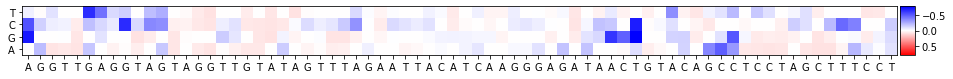

In [8]:
analysisPlot.showMatWithVal(outMat,showText=False,vmin=None,norm = mpl.colors.Normalize(vmin=minVal,vmax=maxVal),cmapName='bwr',
                            xtickLabels=xTickLabels,ytickLabels=yTickLabels,driverCaxSize=0.2,saveFig='3.pdf')
# import matplotlib.pyplot as plt
# plt.savefig('31.pdf',dpi=600)

Sometimes the length will be too long to plot in one figure, we can plot it separately.

In [9]:
windowSize = 20

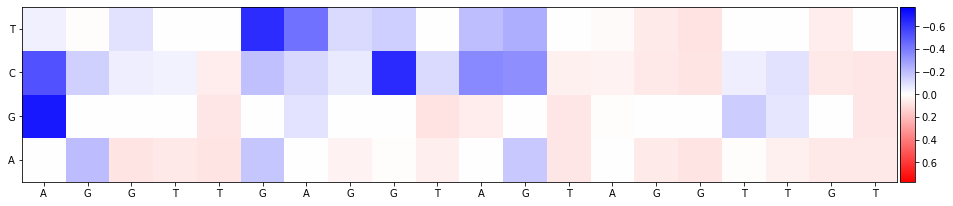

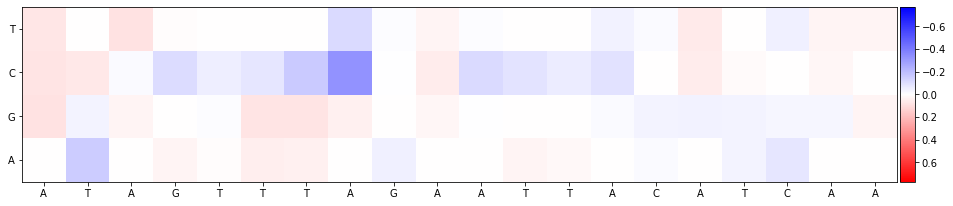

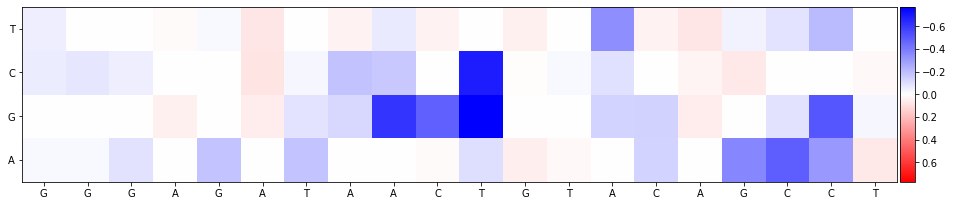

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "D:\ProgramData\Anaconda3\envs\auto\lib\site-packages\IPython\core\interactiveshell.py", line 3457, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\dell\AppData\Local\Temp\ipykernel_10540\2782942074.py", line 7, in <module>
    xtickLabels=xTickLabels[currPos:currPos+windowSize],ytickLabels=yTickLabels,driverCaxSize=0.2)
  File "..\analysisPlot.py", line 182, in showMatWithVal
    ax.set_xticklabels(xtickLabels)
  File "D:\ProgramData\Anaconda3\envs\auto\lib\site-packages\matplotlib\axes\_base.py", line 75, in wrapper
    return get_method(self)(*args, **kwargs)
  File "D:\ProgramData\Anaconda3\envs\auto\lib\site-packages\matplotlib\axis.py", line 1798, in _set_ticklabels
    return self.set_ticklabels(labels, minor=minor, **kwargs)
  File "D:\ProgramData\Anaconda3\envs\auto\lib\site-packages\matplotlib\axis.py", line 1721, in set_ticklabels
    "The number of FixedLocator locations"
ValueError: The number of 

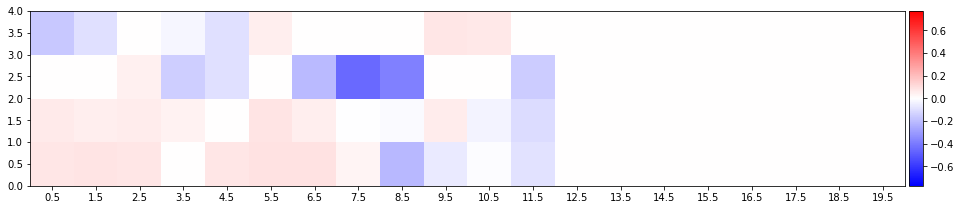

In [ ]:
currPos = 0
totalLen = outMat.shape[1]
while currPos < totalLen:
    currMat = np.zeros([len(tempStr),windowSize])
    currMat[:,:np.min([windowSize, totalLen - currPos])] += outMat[:,currPos:currPos+windowSize]
    analysisPlot.showMatWithVal(currMat,showText=False,vmin=None,norm = mpl.colors.Normalize(vmin=minVal,vmax=maxVal),cmapName='bwr',
                            xtickLabels=xTickLabels[currPos:currPos+windowSize],ytickLabels=yTickLabels,driverCaxSize=0.2)
    currPos += windowSize

That's all the informations for this notebook. If you still have more issues, please fell free to connect us at ljs@swmu.edu.cn, thanks.